In [1]:
# import libraries
import json
from sklearn.model_selection import train_test_split, KFold
from transformers import AutoTokenizer, AutoModelForTokenClassification, logging
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.optim import AdamW
import sys
from pathlib import Path
import optuna
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
import gc
import warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# suppress unproblematic warnings from transformer models
logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="The sentencepiece tokenizer")

# change path to the project root
base_path = Path.cwd() / "../../"
sys.path.append(str(base_path.resolve()))

# load custom classes and functions
from utils.classification import EarlyStopping, train_bert, tune_bert_ner_optuna
from utils.evaluation import run_testset_ner, evaluate_seqeval, mention_level_evaluation, sentence_level_evaluation

In [2]:
# load the annotated data in json format
with open("../../01_data/annotations_reduced.json", "r") as f:
    data = json.load(f)

# initialize tag dictionary
tag_dict = {"O"}

# loop through all sentences
for task in data:
    if task["annotations"]:
        for annotation in task["annotations"]:
            label = annotation["tag"][0:2]
            tag_dict.add(f"B-{label}")
            tag_dict.add(f"I-{label}")

# sort the tag dictionary
tag_list = sorted(tag_dict)

# dictionaries that convert from id to tag and vice versa
tag_to_id = {tag: i for i, tag in enumerate(tag_list)}
id_to_tag = {id: label for label, id in tag_to_id.items()}

In [3]:
def tokenization_labelling(text, entities, tokenizer, tag2id, max_len):

    # get the encoding of the sentence
    encoding = tokenizer(text, return_offsets_mapping=True, truncation=True,
                         max_length=max_len, padding="max_length")
    
    # create preliminary list with O tags for all tokens
    tags = ["O"] * len(encoding.offset_mapping)

    # loop over annotations and extract start and end index as well as the given tag
    for ent in entities:
        start, end = ent["start"], ent["end"]
        ent_tag = ent["tag"][0:2]

        # loop over all tokens in the sentence and check for overlap
        for idx, (token_start, token_end) in enumerate(encoding.offset_mapping):
            # continue if it is a special token
            if token_start == token_end == 0:
                continue
            # check for overlap (overlap checking strictly necessary for deberta)
            if token_end > start and token_start < end:
                # assign B-tag if start is equal or smaller (smaller if deberta)
                if token_start <= start:
                    tags[idx] = f"B-{ent_tag}"
                # otherwise it is an inside token
                else:
                    tags[idx] = f"I-{ent_tag}"

    # extract the word ids
    word_ids = encoding.word_ids()

    # ensure propagate B-tags are propagated to all subwords of the same word (only actually relevant for deberta)
    for idx, wid in enumerate(word_ids):
        if wid is None:
            continue
        # if token has B-tag ensure that all other tokens of the same word get I-tag
        if tags[idx].startswith("B-"):
            for j, wid2 in enumerate(word_ids):
                if wid2 == wid and j != idx:
                    tags[j] = f"I-{ent_tag}"

    # convert tags to IDs, masking special tokens
    tag_ids = [-100 if wid is None else tag2id.get(tag, tag2id["O"])
               for tag, wid in zip(tags, encoding.word_ids())]

    return encoding["input_ids"], encoding["attention_mask"], tag_ids, word_ids

In [4]:
# split into training, validation and test dataset
train_data, val_data = train_test_split(data, test_size=0.2, shuffle=True, random_state=42)

class TokenDataset(Dataset):
    def __init__(self, data, tokenizer, tag2id, max_len):
        self.dataset = []
        self.max_len = max_len

        for task in data:
            # get the sentence and all annotations
            text = task["sentence"]
            spans = task["annotations"]

            # tokenize and get all ids
            input_ids, attention_mask, tag_ids, word_ids = tokenization_labelling(text, spans, tokenizer, tag2id, self.max_len)
            #input_ids, attention_mask, tag_ids, word_ids = bert_tokenization_labelling(text, spans, tokenizer, tag2id, self.max_len, which_model)

            # add everything to the dataset list
            self.dataset.append({
                "input_ids": torch.tensor(input_ids, dtype=torch.long),
                "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
                "tag_ids": torch.tensor(tag_ids, dtype=torch.long),
                "word_ids": word_ids})
  

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

def custom_collate_fn(batch):
    input_ids = torch.stack([item["input_ids"] for item in batch])
    attention_masks = torch.stack([item["attention_mask"] for item in batch])
    tag_ids = torch.stack([item["tag_ids"] for item in batch])
    word_ids = [item["word_ids"] for item in batch]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_masks,
        "tag_ids": tag_ids,
        "word_ids": word_ids
    }

In [6]:
# hyperparameter tuning with TPE implemented via Optuna

# define the objective function whose output optuna tries to maximize
def objective(trial, model_name, train_dataset, val_dataset, collate_fn, tag2id, id2tag, device, early_stopper):

    # hyperparameter space in which optuna can search
    params = {
        "lr": trial.suggest_categorical("lr", [9e-6, 2e-5, 4e-5]),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
        "weight_decay": trial.suggest_categorical("weight_decay", [0.01, 0.1, 0.3]),
        "epochs": trial.suggest_categorical("epochs", [2, 2, 2])
    }

    # train the model with these hyperparameters
    best_f1, best_epoch, train_losses, val_losses, f1_scores_train, f1_scores_val = tune_bert_ner_optuna(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        collate_fn=collate_fn,
        model_name=model_name,
        tag2id=tag2id,
        id2tag=id2tag,
        device=device,
        early_stopper=early_stopper,
        params=params
    )

    # besides parameters, save losses and f1-scores in the trial object
    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("train_losses", train_losses)
    trial.set_user_attr("val_losses", val_losses)
    trial.set_user_attr("f1_scores_train", f1_scores_train)
    trial.set_user_attr("f1_scores_val", f1_scores_val)

    return best_f1


# dictionary to save optimal paramaters
optimal_configs = {}

# number of trials, the device on which models should operate and the specific models to test
num_trials = 2
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model_names = ["microsoft/deberta-v3-base", "roberta-base", "bert-base-cased", "distilbert-base-cased"]

# loop over the models
for model_name in model_names:

    print(f"\nStarting search for model: {model_name}")
    print("-"*200)

    # create a new optuna study, tokenizer fitting to the model as well as train and validation set
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = TokenDataset(data=train_data, tokenizer=tokenizer, tag2id=tag_to_id)
    val_dataset = TokenDataset(data=val_data, tokenizer=tokenizer, tag2id=tag_to_id)

    # run the optimization loop
    study.optimize(
        partial(objective,
                model_name=model_name,
                train_dataset=train_dataset,
                val_dataset=val_dataset,
                collate_fn=custom_collate_fn,
                tag2id=tag_to_id,
                id2tag=id_to_tag,
                device=device,
                early_stopper=EarlyStopping(patience=3, path=f"model_saves/{model_name}_checkpoint", printoption=True)),
        n_trials=num_trials
    )

    # get the best trial and save optimal parameters
    best_trial = study.best_trial
    optimal_configs[model_name] = {
        "best_f1": best_trial.value,
        "best_params": best_trial.params,
        "best_epoch": best_trial.user_attrs["best_epoch"],
        "train_losses": best_trial.user_attrs["train_losses"],
        "val_losses": best_trial.user_attrs["val_losses"],
        "f1_scores_train": best_trial.user_attrs["f1_scores_train"],
        "f1_scores_val": best_trial.user_attrs["f1_scores_val"]
    }

    # clean all objects and empty cache for the next model
    del study, tokenizer, train_dataset, val_dataset
    gc.collect()
    torch.mps.empty_cache()

    print("-"*200)

[I 2025-11-05 09:00:24,995] A new study created in memory with name: no-name-79704a25-fb21-4489-9060-17005351bf6f



Starting search for model: roberta-base
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Trial with params: {'lr': 9e-06, 'batch_size': 16, 'weight_decay': 0.1, 'epochs': 2}


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch 1/2


Training: 100%|██████████| 5/5 [00:02<00:00,  1.70it/s, loss=0.716]


...

Average training loss: 0.7284
Epoch 2/2


Training: 100%|██████████| 5/5 [00:00<00:00,  5.00it/s, loss=0.419]


Average training loss: 0.4933


[I 2025-11-05 09:00:59,036] Trial 1 finished with value: 0.0 and parameters: {'lr': 9e-06, 'batch_size': 16, 'weight_decay': 0.3, 'epochs': 2}. Best is trial 0 with value: 0.0.


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


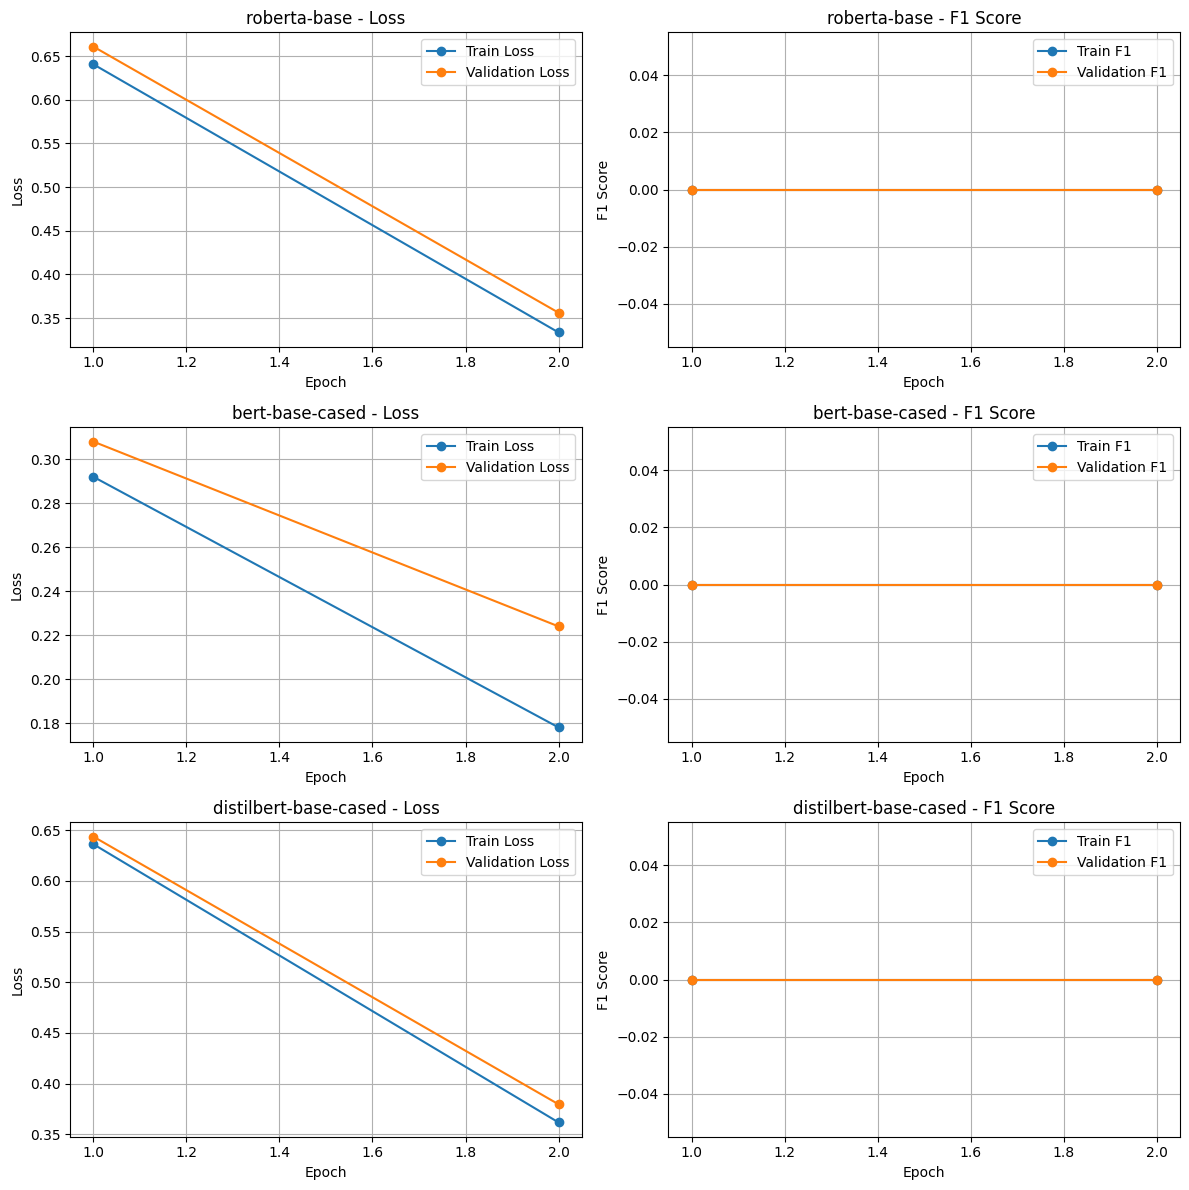

In [8]:
# plot the development of F1 scores and losses for the tuned models

# as many rows as models and 2 columns for loss and f1
fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 4 * len(model_names)))

# loop over the models
for i, model_name in enumerate(model_names):

    # get the data for this specific model
    config = optimal_configs[model_name]
    epochs = list(range(1, len(config['train_losses']) + 1))

    # create the loss subplot
    ax_loss = axes[i, 0]
    ax_loss.plot(epochs, config['train_losses'], marker='o', label='Train Loss')
    ax_loss.plot(epochs, config['val_losses'], marker='o', label='Validation Loss')
    ax_loss.set_title(f"{model_name} - Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True)

    # create the F1 subplot
    ax_f1 = axes[i, 1]
    ax_f1.plot(epochs, config['f1_scores_train'], marker='o', label='Train F1')
    ax_f1.plot(epochs, config['f1_scores_val'], marker='o', label='Validation F1')
    ax_f1.set_title(f"{model_name} - F1 Score")
    ax_f1.set_xlabel("Epoch")
    ax_f1.set_ylabel("F1 Score")
    ax_f1.legend()
    ax_f1.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# apply cross validation to all models with their best hyperparameters

# empty dictionary to store the final average metrics
average_metrics = {}

# loop over all individual models
for model_name in model_names:

    print(f"\nCross-validation for model {model_name} starts")
    print("-"*200)

    # dictionary to save the individual fold evaluation metrics
    fold_metrics = {
        "seqeval": [],
        "cross_span": [],
        "sentence_level": []
    }

    # get the optimal hyperparameters for this model
    epochs = optimal_configs[model_name]["best_epoch"]
    lr = optimal_configs[model_name]["best_params"]["lr"]
    batch_size = optimal_configs[model_name]["best_params"]["batch_size"]
    weight_decay = optimal_configs[model_name]["best_params"]["weight_decay"]

    # define the tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # create cross-validation object for 5 folds
    k = 5
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # randomly split the training data into 5 folds and loop over them
    for fold, (train_idx, val_idx) in enumerate(kf.split(train_data)):

        print(f"\nFold number: {fold + 1}")

        # create the training and validation fold based on the provided indices
        train_fold_data = [train_data[i] for i in train_idx]
        val_fold_data = [train_data[i] for i in val_idx]

        # create tensor dataset and respective data loaders
        train_dataset = TokenDataset(data=train_fold_data, tokenizer=tokenizer, tag2id=tag_to_id)
        val_dataset = TokenDataset(data=val_fold_data, tokenizer=tokenizer, tag2id=tag_to_id)
        train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
        val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)

        # set the device explicitly
        device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

        # create the model and optimizer
        model = AutoModelForTokenClassification.from_pretrained(
            model_name,
            num_labels=len(tag_to_id),
            id2label=id_to_tag,
            label2id=tag_to_id
            ).to(device)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        # train the model with the optimal configuration
        train_bert(train_dataloader, model, optimizer, epochs, device, which_task="ner")

        # create dictionary to save the inputs for each evaluation metric
        evaluation_inputs = {
        "seqeval": {},
        "cross_span": {},
        "sentence_level": {}
        }
        
        # loop over all metrics and get the ground truth as well as predicted labels for the validation set
        for metric in evaluation_inputs.keys():
            all_true, all_pred, _ = run_testset_ner(
                model=model, test_dataloader=val_dataloader, id2tag=id_to_tag, device=device, for_metric=metric
                )
            evaluation_inputs[metric] = {
                "all_true": all_true,
                "all_pred":all_pred
                }
            
        # apply all evaluation functions and save in the dictionary
        metrics_seqeval = evaluate_seqeval(
        evaluation_inputs["seqeval"]["all_true"],
        evaluation_inputs["seqeval"]["all_pred"]
        )
        metrics_cross_span = mention_level_evaluation(
            evaluation_inputs["cross_span"]["all_true"],
            evaluation_inputs["cross_span"]["all_pred"]
        )
        metrics_sentence_level = sentence_level_evaluation(
            evaluation_inputs["sentence_level"]["all_true"],
            evaluation_inputs["sentence_level"]["all_pred"]
        )

        # append all metrics to the dictionary
        fold_metrics["seqeval"].append(metrics_seqeval)
        fold_metrics["cross_span"].append(metrics_cross_span)
        fold_metrics["sentence_level"].append(metrics_sentence_level)

    # calculate average metrics for all scores
    seqeval_scores = [m["f1"] for m in fold_metrics["seqeval"]]
    mean_seqeval = np.mean(seqeval_scores)
    std_seqeval = np.std(seqeval_scores)

    cross_span_scores = [m["f1"] for m in fold_metrics["cross_span"]]
    mean_cross_span = np.mean(cross_span_scores)
    std_cross_span = np.std(cross_span_scores)

    sentence_level_scores = [m["f1"] for m in fold_metrics["sentence_level"]]
    mean_sentence_level = np.mean(sentence_level_scores)
    std_sentence_level = np.std(sentence_level_scores)

    # append all metrics to the dictionary
    average_metrics[model_name] = {
        "seqeval": mean_seqeval,
        "cross_span": mean_cross_span,
        "sentence_level": mean_sentence_level
        }
    
    print("-"*200)


Cross-validation for model roberta-base starts
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold number: 1
Epoch 1/1


Training: 100%|██████████| 4/4 [00:01<00:00,  2.03it/s, loss=0.424]


Average training loss: 0.5186


/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Fold number: 2
Epoch 1/1


...

Average training loss: 1.3605
Fold number: 4
Epoch 1/1


Training: 100%|██████████| 2/2 [00:00<00:00,  2.62it/s, loss=0.988]


Average training loss: 1.0601
Fold number: 5
Epoch 1/1


Training: 100%|██████████| 2/2 [00:00<00:00,  2.65it/s, loss=1.19]

Average training loss: 1.2889
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
# export the cross-validation metrics
with open("eval_results/evaluation_metrics_bert.json", "w") as f:
    json.dump(average_metrics, f, indent=4)

In [10]:
def predict_sentence(sentence, model, tokenizer, id_to_label, device='mps'):

    model.eval()

    # tokenize the input sentence
    encoding = tokenizer(
        sentence,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
        max_length=128
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    offset_mapping = encoding["offset_mapping"][0]

    # inference with autocast for mixed precision
    with torch.no_grad():
        with torch.autocast(device_type=device, dtype=torch.float16):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)[0]

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    labels = [id_to_label[pred.item()] for pred in predictions]

    result = []
    for token, label, (start, end) in zip(tokens, labels, offset_mapping):
        if start == 0 and end == 0:
            continue
        token_text = sentence[start:end]
        result.append((token_text, label))

    return result

In [14]:
# try out a custom sentence
text = "We want to protect women."
predict_sentence(text, model=model, tokenizer=tokenizer, id_to_label=id_to_tag)

[('We', 'O'),
 (' want', 'O'),
 (' to', 'O'),
 (' protect', 'O'),
 (' women', 'B-sg'),
 ('.', 'I-sg')]